In [ ]:
import matplotlib.pyplot as plt
import statsmodels.api as sm
import numpy as np
import pandas as pd

pd.options.display.float_format = '{:.2f}'.format

In [ ]:
qSales = pd.read_csv('qSales_2024.csv')

display(qSales)

,gvkey,datadate,fyearq,fqtr,fyr,indfmt,consol,popsrc,datafmt,tic,conm,curcdq,datacqtr,datafqtr,saleq,costat
0,1690,2001-03-31,2001,2,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2001Q1,2001Q2,1431.00,A
1,1690,2001-06-30,2001,3,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2001Q2,2001Q3,1475.00,A
2,1690,2001-09-30,2001,4,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2001Q3,2001Q4,1450.00,A
3,1690,2001-12-31,2002,1,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2001Q4,2002Q1,1375.00,A
4,1690,2002-03-31,2002,2,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2002Q1,2002Q2,1495.00,A
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
272,102450,2022-12-31,2022,3,3,INDL,C,D,STD,NTDOY,NINTENDO CO LTD,USD,2022Q4,2022Q3,5280.78,A
273,102450,2023-03-31,2022,4,3,INDL,C,D,STD,NTDOY,NINTENDO CO LTD,USD,2023Q1,2022Q4,2226.88,A
274,102450,2023-06-30,2023,1,3,INDL,C,D,STD,NTDOY,NINTENDO CO LTD,USD,2023Q2,2023Q1,3190.81,A
275,102450,2023-09-30,2023,2,3,INDL,C,D,STD,NTDOY,NINTENDO CO LTD,USD,2023Q3,2023Q2,2140.04,A


In [ ]:
qSales['datadate'] = pd.to_datetime(qSales['datadate'])

In [ ]:
target_sales = qSales.loc[qSales['tic']=='TGT']

display(target_sales)

,gvkey,datadate,fyearq,fqtr,fyr,indfmt,consol,popsrc,datafmt,tic,conm,curcdq,datacqtr,datafqtr,saleq,costat
92,3813,2001-01-31,2000,4,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2000Q4,2000Q4,12324.00,A
93,3813,2001-04-30,2001,1,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q1,2001Q1,8334.00,A
94,3813,2001-07-31,2001,2,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q2,2001Q2,8941.00,A
95,3813,2001-10-31,2001,3,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q3,2001Q3,9331.00,A
96,3813,2002-01-31,2001,4,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q4,2001Q4,13220.00,A
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180,3813,2023-01-31,2022,4,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2022Q4,2022Q4,31395.00,A
181,3813,2023-04-30,2023,1,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2023Q1,2023Q1,25322.00,A
182,3813,2023-07-31,2023,2,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2023Q2,2023Q2,24773.00,A
183,3813,2023-10-31,2023,3,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2023Q3,2023Q3,25398.00,A


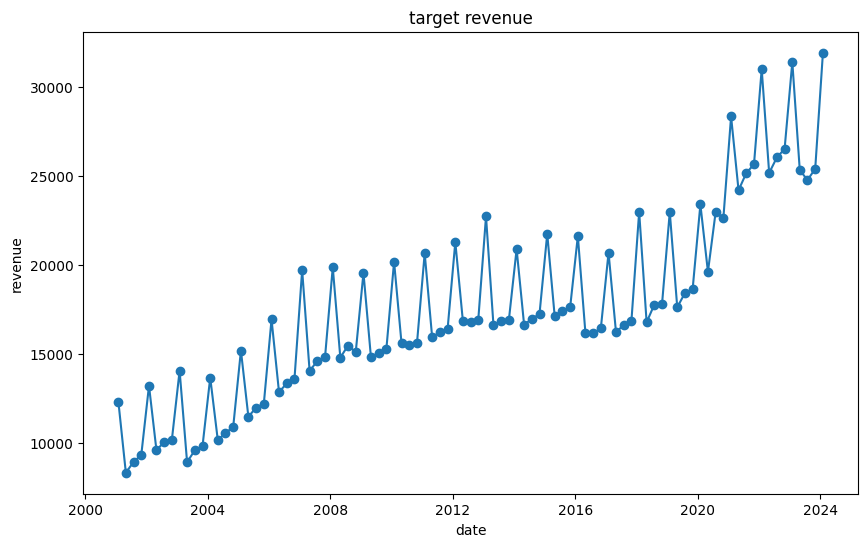

In [ ]:
plt.figure(figsize=(10,6))

plt.title('target revenue')

plt.xlabel('date')
plt.ylabel('revenue')

plt.plot(target_sales['datadate'],target_sales['saleq'],marker='o')

In [ ]:
target_sales['time'] = range(1, len(target_sales) + 1)

display(target_sales)

/tmp/ipykernel_1077/1685311324.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  target_sales['time'] = range(1, len(target_sales) + 1)


,gvkey,datadate,fyearq,fqtr,fyr,indfmt,consol,popsrc,datafmt,tic,conm,curcdq,datacqtr,datafqtr,saleq,costat,time
92,3813,2001-01-31,2000,4,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2000Q4,2000Q4,12324.00,A,1
93,3813,2001-04-30,2001,1,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q1,2001Q1,8334.00,A,2
94,3813,2001-07-31,2001,2,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q2,2001Q2,8941.00,A,3
95,3813,2001-10-31,2001,3,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q3,2001Q3,9331.00,A,4
96,3813,2002-01-31,2001,4,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q4,2001Q4,13220.00,A,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180,3813,2023-01-31,2022,4,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2022Q4,2022Q4,31395.00,A,89
181,3813,2023-04-30,2023,1,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2023Q1,2023Q1,25322.00,A,90
182,3813,2023-07-31,2023,2,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2023Q2,2023Q2,24773.00,A,91
183,3813,2023-10-31,2023,3,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2023Q3,2023Q3,25398.00,A,92


In [ ]:
# dummy 1 - holiday quarter, target's nov-jan selling season
# dummy 2 - covid, target's revenue base stepped up permanently in 2020

target_sales['holiday_dv'] = np.where(target_sales['fqtr']==4,1,0)
target_sales['covid_dv'] = np.where(target_sales['datadate']>='2020-04-30',1,0)

display(target_sales)

/tmp/ipykernel_1077/3156214568.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  target_sales['holiday_dv'] = np.where(target_sales['fqtr']==4,1,0)
/tmp/ipykernel_1077/3156214568.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  target_sales['covid_dv'] = np.where(target_sales['datadate']>='2020-04-30',1,0)


,gvkey,datadate,fyearq,fqtr,fyr,indfmt,consol,popsrc,datafmt,tic,conm,curcdq,datacqtr,datafqtr,saleq,costat,time,holiday_dv,covid_dv
92,3813,2001-01-31,2000,4,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2000Q4,2000Q4,12324.00,A,1,1,0
93,3813,2001-04-30,2001,1,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q1,2001Q1,8334.00,A,2,0,0
94,3813,2001-07-31,2001,2,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q2,2001Q2,8941.00,A,3,0,0
95,3813,2001-10-31,2001,3,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q3,2001Q3,9331.00,A,4,0,0
96,3813,2002-01-31,2001,4,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q4,2001Q4,13220.00,A,5,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180,3813,2023-01-31,2022,4,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2022Q4,2022Q4,31395.00,A,89,1,1
181,3813,2023-04-30,2023,1,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2023Q1,2023Q1,25322.00,A,90,0,1
182,3813,2023-07-31,2023,2,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2023Q2,2023Q2,24773.00,A,91,0,1
183,3813,2023-10-31,2023,3,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2023Q3,2023Q3,25398.00,A,92,0,1


In [ ]:
x = target_sales.loc[:,['time','holiday_dv','covid_dv']]
x = sm.add_constant(x)

y = target_sales.loc[:,'saleq']

model_dummy = sm.OLS(y,x).fit()

model_dummy.params

,0
const,9447.95
time,130.01
holiday_dv,4835.37
covid_dv,4233.24


In [ ]:
model_dummy.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  saleq   R-squared:                       0.946
Model:                            OLS   Adj. R-squared:                  0.944
Method:                 Least Squares   F-statistic:                     517.8
Date:                Sat, 25 Jul 2026   Prob (F-statistic):           3.38e-56
Time:                        00:17:03   Log-Likelihood:                -793.71
No. Observations:                  93   AIC:                             1595.
Df Residuals:                      89   BIC:                             1606.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       9447.9507    298.392     31.663      0.000    8855.052       1e+04
time         130.0128      6.423     20.241      0.000     117.250     142.776
holiday_dv  4835.3658    298.216     16.214      0.000    4242.816    5427.915
covid_dv    4233.2372    456.903      9.265      0.000    3325.381    5141.093
==============================================================================
Omnibus:                        3.185   Durbin-Watson:                   0.395
Prob(Omnibus):                  0.203   Jarque-Bera (JB):                3.062
Skew:                          -0.440   Prob(JB):                        0.216
Kurtosis:                       2.868   Cond. No.                         199.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [ ]:
predictions = model_dummy.predict(x)

display(predictions)

,0
92,14413.33
93,9707.98
94,9837.99
95,9968.00
96,14933.38
...,...
180,30087.69
181,25382.34
182,25512.35
183,25642.37


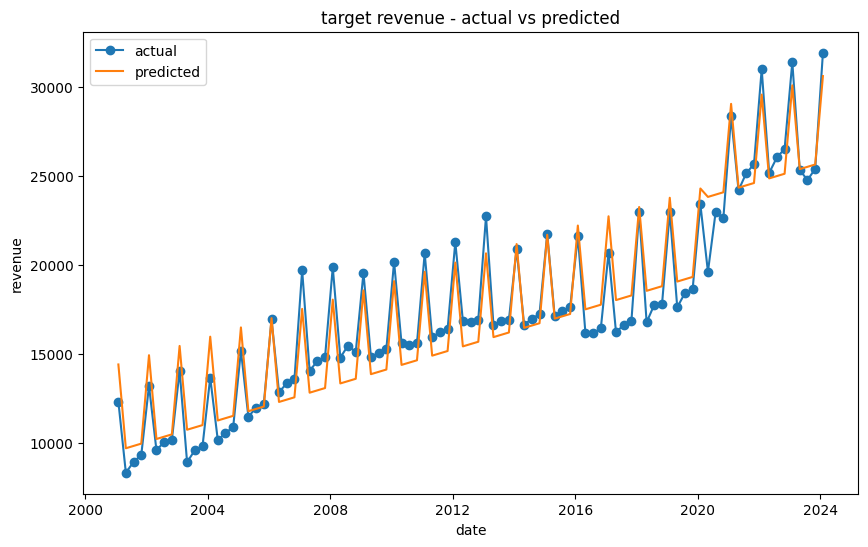

In [ ]:
plt.figure(figsize=(10,6))

plt.title('target revenue - actual vs predicted')

plt.xlabel('date')
plt.ylabel('revenue')

plt.plot(target_sales['datadate'],target_sales['saleq'],marker='o',label='actual')
plt.plot(target_sales['datadate'],predictions,label='predicted')

plt.legend()

In [ ]:
model_dummy.get_prediction(x).summary_frame(alpha=0.2)

,mean,mean_se,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper
92,14413.33,360.08,13948.42,14878.24,12723.45,16103.21
93,9707.98,287.72,9336.50,10079.46,8041.38,11374.58
94,9837.99,282.45,9473.31,10202.67,8172.89,11503.08
95,9968.00,277.23,9610.07,10325.94,8304.37,11631.63
96,14933.38,343.06,14490.44,15376.32,13249.41,16617.35
...,...,...,...,...,...,...
180,30087.69,386.55,29588.61,30586.78,28388.09,31787.29
181,25382.34,324.63,24963.20,25801.49,23704.47,27060.21
182,25512.35,325.28,25092.37,25932.33,23834.28,27190.43
183,25642.37,326.05,25221.39,26063.34,23964.04,27320.69


**Memo: Target Corporation Revenue Analysis**

To: Chapman Wealth Management
From: QuantFolio Solutions
Re: Target Corporation (TGT) Quarterly Revenue Model
Date: July 2026

We modelled 93 quarters of Target's revenue (FY2000 Q4 to FY2023 Q4) using time plus two dummy variables.

The model: Revenue = 9,447.95 + 130.01(time) + 4,835.37(holiday) + 4,233.24(post-2020), in millions of dollars.

**The two dummy variables**

The holiday dummy captures Target's fiscal Q4, which runs November through January. That quarter runs about 4.84 billion dollars above a normal quarter, driven by holiday spending on discretionary and general merchandise.

The post-2020 dummy captures a structural jump in Target's revenue base starting in 2020, worth about 4.23 billion dollars per quarter. It reflects shifted consumer demand plus the inflation that followed. The key point is that it was permanent. Revenue never came back down to the old trend.

Both are significant at p below 0.001.

**Model fit**

The model explains about 95 percent of the variation in Target's quarterly revenue (R squared of 0.946). All three variables are significant. Target's revenue is highly predictable.

Two caveats. The model slightly overpredicts early 2000s holiday quarters, since it treats the holiday premium as a fixed dollar amount. And our data ends January 2024, so it should be refreshed before any live decision.

**What this means for the investment decision**

Organic growth is modest. Stripping out the 2020 jump, Target grows about 130 million dollars per quarter, or 520 million a year.

The most important finding: our first model, before we isolated the 2020 shift, showed growth of 164 million per quarter. The trend line was absorbing the structural break and overstating growth by roughly 26 percent. Any valuation extrapolating post-2020 growth forward will likely be too optimistic. A large share of today's revenue base is a one-time reset, not compounding growth.

On the positive side, predictability this strong supports stable cash flow forecasting.

The main risk is Q4 concentration. With 4.8 billion riding on one quarter a year, a weak holiday season hits hard.